# Respiratory Disease Screening, Exploratory Data Analysis

This notebook profiles three raw datasets before any modeling work:

- **COUGHVID_v3**, crowdsourced cough recordings with self-report and expert labels
- **TB_screen**, forced and passive cough recordings with clinical metadata
- **West China**, cough recordings labeled by directory name only, no metadata file

All reusable EDA logic lives in `src/utils/eda_utils.py` and is imported below,
this notebook is intentionally kept to "load, inspect, call, decide", not raw
logic. Run `pip install -e .` once from the project root, this makes
`from utils.eda_utils import ...` work from anywhere in the project with no
`sys.path` manipulation.

## 0. Setup

In [20]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import seaborn as sns

from utils.eda_utils import (
    # core profiling
    profile_dataframe, missingness_report, dtype_audit, cardinality_report,
    outlier_summary, class_balance_report, duplicate_check, save_profile_report,
    # audio
    audio_file_integrity_check, audio_metadata_extract,
    duration_distribution_report, silence_and_clipping_check,
    # coughvid
    join_key_validation, label_agreement_analysis, label_vs_selfreport_comparison,
    demographic_breakdown, extracted_feature_distributions,
    feature_label_correlation, audio_quality_flags,
    # tb_screen
    forced_vs_passive_comparison, patient_level_aggregation_check,
    tb_status_distribution, metadata_completeness_by_class,
    cross_dataset_schema_diff,
    # west china
    build_label_dataframe_from_dirs, filename_pattern_audit,
    spectrogram_sample_grid,
    # cross-dataset
    schema_alignment_matrix, label_taxonomy_reconciliation, dataset_shift_check,
)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


In [21]:
ROOT = Path.cwd().parent
DATA_DIR = ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
COUGHS_DIR = RAW_DIR / "coughs"
COUGHVID_DIR = COUGHS_DIR/ "COUGHVID_V3"
TB_DIR = COUGHS_DIR / "TBscreen_Dataset"
WEST_CHINA_DIR = COUGHS_DIR / "West_China_Uni"
BRONCHITIS_DIR = WEST_CHINA_DIR / "bronchitis"
PNEUMONIA_DIR = WEST_CHINA_DIR / "pneumonia"
ARTIFACTS_DIR = ROOT / "artifacts"

In [22]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return pd.read_csv(path, low_memory=False)  # mixed-type columns, avoid dtype warnings


# COUGHVID_v3
coughvid_df = load_csv(COUGHVID_DIR / "tabular_form" / "coughvid_v3.csv")
coughvid_extr_features_df = load_csv(COUGHVID_DIR / "tabular_form" / "extracted_features_coughvid_v3.csv")
coughvid_filtered_exp_lbls = load_csv(COUGHVID_DIR / "tabular_form" / "filtered_expert_labels_coughvid_v3.csv")

# TB_screen
tb_forced_df = load_csv(TB_DIR / "Forced_coughs" / "Forced_coughs.csv")
tb_passive_df = load_csv(TB_DIR / "Passive_coughs" / "Passive_coughs.csv")
tb_metadata_df = load_csv(TB_DIR / "metadata.csv")

# West China, no metadata file, labels come from directory names
# (bronchitis / pneumonia), built below in section 3


### 0.1 Inspect raw schema before assuming any join keys

In [23]:
for name, df in [
    ("coughvid_df", coughvid_df),
    ("coughvid_extr_features_df", coughvid_extr_features_df),
    ("coughvid_filtered_exp_lbls", coughvid_filtered_exp_lbls),
    ("tb_forced_df", tb_forced_df),
    ("tb_passive_df", tb_passive_df),
    ("tb_metadata_df", tb_metadata_df),
]:
    print(f"{name}: {df.columns.tolist()}\n")


coughvid_df: ['datetime', 'cough_detected', 'latitude', 'longitude', 'age', 'gender', 'respiratory_condition', 'fever_muscle_pain', 'status', 'file_name', 'audio_name']

coughvid_extr_features_df: ['MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4', 'MFCC_5', 'MFCC_6', 'MFCC_7', 'MFCC_8', 'MFCC_9', 'MFCC_10', 'MFCC_11', 'MFCC_12', 'MFCC_13', 'Chroma_1', 'Chroma_2', 'Chroma_3', 'Chroma_4', 'Chroma_5', 'Chroma_6', 'Chroma_7', 'Chroma_8', 'Chroma_9', 'Chroma_10', 'Chroma_11', 'Chroma_12', 'SpectralContrast_1', 'SpectralContrast_2', 'SpectralContrast_3', 'SpectralContrast_4', 'SpectralContrast_5', 'SpectralContrast_6', 'SpectralContrast_7', 'ZeroCrossingRate', 'SpectralCentroid', 'status', 'fever_muscle_pain', 'gender']

coughvid_filtered_exp_lbls: ['datetime', 'cough_detected', 'latitude', 'longitude', 'age', 'gender', 'respiratory_condition', 'fever_muscle_pain', 'status', 'file_name', 'audio_name', 'expert_labels_1.quality', 'expert_labels_1.cough_type', 'expert_labels_1.dyspnea', 'expert_labels_1.

# 1.10 COUGHVID_DF

## 1.11 Baseline profile

In [24]:
profile_dataframe(coughvid_df, name="coughvid_metadata")


PROFILE: coughvid_metadata
shape: (34434, 11)
memory: 15.62 MB
duplicate rows: 0

dtypes:
datetime                  object
cough_detected           float64
latitude                 float64
longitude                float64
age                      float64
gender                    object
respiratory_condition     object
fever_muscle_pain         object
status                    object
file_name                 object
audio_name                object
dtype: object

head:
                           datetime  cough_detected  latitude  longitude  \
0  2020-04-13T16:30:16.716367+00:00          0.9761      41.8       61.1   
1  2020-11-02T07:42:22.878931+00:00          0.0217       NaN        NaN   
2  2020-11-18T20:30:54.833009+00:00          0.9886      42.4        3.2   
3  2020-11-27T11:10:09.815282+00:00          0.8499       NaN        NaN   
4  2020-04-11T16:12:17.509769+00:00          0.7665       NaN        NaN   

    age  gender respiratory_condition fever_muscle_pain   status  \


DataFrameProfile(name='coughvid_metadata', shape=(34434, 11), dtypes=datetime                  object
cough_detected           float64
latitude                 float64
longitude                float64
age                      float64
gender                    object
respiratory_condition     object
fever_muscle_pain         object
status                    object
file_name                 object
audio_name                object
dtype: object, n_duplicate_rows=0, memory_mb=np.float64(15.619255), head=                           datetime  cough_detected  latitude  longitude  \
0  2020-04-13T16:30:16.716367+00:00          0.9761      41.8       61.1   
1  2020-11-02T07:42:22.878931+00:00          0.0217       NaN        NaN   
2  2020-11-18T20:30:54.833009+00:00          0.9886      42.4        3.2   
3  2020-11-27T11:10:09.815282+00:00          0.8499       NaN        NaN   
4  2020-04-11T16:12:17.509769+00:00          0.7665       NaN        NaN   

    age  gender respiratory_condition 

## 1.12 Missingness, dtypes, cardinality

In [25]:
missingness_report(coughvid_df)

,column,n_missing,pct_missing,flagged
0,age,15038,0.4367,True
1,longitude,15003,0.4357,True
2,latitude,15003,0.4357,True
3,fever_muscle_pain,13770,0.3999,False
4,status,13770,0.3999,False
5,gender,13770,0.3999,False
6,respiratory_condition,13770,0.3999,False
7,cough_detected,0,0.0000,False
8,datetime,0,0.0000,False
9,file_name,0,0.0000,False


In [26]:
dtype_audit(coughvid_df)

,column,current_dtype,suspected_type,n_unique,sample_values
0,datetime,object,object,34434,"[2020-04-13T16:30:16.716367+00:00, 2020-11-02T..."
1,cough_detected,float64,float64,7958,"[0.9761, 0.0217, 0.9886, 0.8499, 0.7665]"
2,latitude,float64,float64,834,"[41.8, 42.4, 38.5, 48.6, 47.3]"
3,longitude,float64,float64,1551,"[61.1, 3.2, 27.1, 2.1, 8.3]"
4,age,float64,float64,99,"[17.0, 62.0, 39.0, 73.0, 37.0]"
5,gender,object,categorical (low cardinality object),3,"[female, male, other]"
6,respiratory_condition,object,numeric (object-cast),2,"[True, False]"
7,fever_muscle_pain,object,numeric (object-cast),2,"[False, True]"
8,status,object,categorical (low cardinality object),3,"[healthy, symptomatic, COVID-19]"
9,file_name,object,object,34434,"[0f0762c8-4b9a-4c1e-a6c3-230f9d53de47.json, 1e..."


In [27]:
cardinality_report(coughvid_df)

,column,n_unique,unique_ratio,top_value_ratio,likely_id_column,near_constant
0,datetime,34434,1.0000,0.0000,True,False
1,audio_name,34434,1.0000,0.0000,True,False
2,file_name,34434,1.0000,0.0000,True,False
3,cough_detected,7958,0.2311,0.0023,False,False
4,longitude,1551,0.0450,0.0191,False,False
5,latitude,834,0.0242,0.0302,False,False
6,age,99,0.0029,0.0346,False,False
7,respiratory_condition,2,0.0001,0.8279,False,False
8,gender,3,0.0001,0.6219,False,False
9,status,3,0.0001,0.7489,False,False


## 1.13 Outliers Summary

In [28]:
outlier_summary(coughvid_df)

,column,n_outliers,pct_outliers,lower_bound,upper_bound
0,longitude,4516,0.2324,-58.2500,86.9500
1,latitude,2899,0.1492,14.8000,65.2000
2,age,151,0.0078,-6.5000,77.5000
3,cough_detected,0,0.0000,-0.9531,2.1355


## 1.14 Class Balance

In [29]:
class_balance_report(coughvid_df, label_col="status")

,status,count,proportion
0,healthy,15476,0.4494
1,NaN,13770,0.3999
2,symptomatic,3873,0.1125
3,COVID-19,1315,0.0382


## 1.15 Duplicates Report

In [30]:
duplicate_check(coughvid_df)

{'n_exact_duplicates': 0,
 'exact_duplicate_rows': Empty DataFrame
 Columns: [datetime, cough_detected, latitude, longitude, age, gender, respiratory_condition, fever_muscle_pain, status, file_name, audio_name]
 Index: []}

### 1.16 Demographic breakdown vs label

Check for demographic skew in the label distribution, age, gender.

In [ ]:
demo_results = demographic_breakdown(
    coughvid_df,
    demo_cols=["age", "gender", "respiratory_condition"],
    label_col="status",
)
demo_results.get("gender")

status,COVID-19,healthy,symptomatic
gender,,,
female,0.0763,0.7122,0.2115
male,0.0541,0.7722,0.1737
other,0.2576,0.6212,0.1212


## 1.16 Audio quality flags

COUGHVID ships SNR and cough-detection-confidence columns, flag rows below usable thresholds before deciding on a filtering cutoff.

In [ ]:
coughvid_flagged = audio_quality_flags(coughvid_df, cough_detect_col="cough_detected")
coughvid_flagged[["low_cough_confidence_flag"]].mean()

low_cough_confidence_flag    0.461463
dtype: float64

## 1.17 Save Profile Report

In [33]:
save_profile_report(coughvid_df, path=ARTIFACTS_DIR / "eda_reports")

ModuleNotFoundError: No module named 'pkg_resources'

# 1.20 COUGHVID Extracted Features

## 1.21 Baseline Profile

In [34]:
profile_dataframe(coughvid_extr_features_df, name="coughvid_extracted_features")


PROFILE: coughvid_extracted_features
shape: (34424, 37)
memory: 13.71 MB
duplicate rows: 77

dtypes:
MFCC_1                float64
MFCC_2                float64
MFCC_3                float64
MFCC_4                float64
MFCC_5                float64
MFCC_6                float64
MFCC_7                float64
MFCC_8                float64
MFCC_9                float64
MFCC_10               float64
MFCC_11               float64
MFCC_12               float64
MFCC_13               float64
Chroma_1              float64
Chroma_2              float64
Chroma_3              float64
Chroma_4              float64
Chroma_5              float64
Chroma_6              float64
Chroma_7              float64
Chroma_8              float64
Chroma_9              float64
Chroma_10             float64
Chroma_11             float64
Chroma_12             float64
SpectralContrast_1    float64
SpectralContrast_2    float64
SpectralContrast_3    float64
SpectralContrast_4    float64
SpectralContrast_5    float6

DataFrameProfile(name='coughvid_extracted_features', shape=(34424, 37), dtypes=MFCC_1                float64
MFCC_2                float64
MFCC_3                float64
MFCC_4                float64
MFCC_5                float64
MFCC_6                float64
MFCC_7                float64
MFCC_8                float64
MFCC_9                float64
MFCC_10               float64
MFCC_11               float64
MFCC_12               float64
MFCC_13               float64
Chroma_1              float64
Chroma_2              float64
Chroma_3              float64
Chroma_4              float64
Chroma_5              float64
Chroma_6              float64
Chroma_7              float64
Chroma_8              float64
Chroma_9              float64
Chroma_10             float64
Chroma_11             float64
Chroma_12             float64
SpectralContrast_1    float64
SpectralContrast_2    float64
SpectralContrast_3    float64
SpectralContrast_4    float64
SpectralContrast_5    float64
SpectralContrast_6   

## 1.22 Missingness, dtypes, cardinality

In [35]:
missingness_report(coughvid_extr_features_df)

,column,n_missing,pct_missing,flagged
0,status,13769,0.4,False
1,fever_muscle_pain,13769,0.4,False
2,gender,13769,0.4,False
3,MFCC_2,0,0.0,False
4,MFCC_1,0,0.0,False
5,MFCC_5,0,0.0,False
6,MFCC_4,0,0.0,False
7,MFCC_3,0,0.0,False
8,MFCC_6,0,0.0,False
9,MFCC_10,0,0.0,False


In [36]:
dtype_audit(coughvid_extr_features_df)

,column,current_dtype,suspected_type,n_unique,sample_values
0,MFCC_1,float64,float64,34173,"[-518.1457, -929.85876, -523.8103, -513.8719, ..."
1,MFCC_2,float64,float64,34231,"[91.433334, 73.61197, 60.157337, 42.908817, 56..."
2,MFCC_3,float64,float64,34252,"[-23.301477, 4.5213194, -5.048457, 3.3450773, ..."
3,MFCC_4,float64,float64,34239,"[5.243495, 27.07968, 0.72083205, 8.316735, 9.6..."
4,MFCC_5,float64,float64,34256,"[-0.2222452, 13.028162, -4.724584, 1.2657201, ..."
5,MFCC_6,float64,float64,34247,"[-9.79092, 1.4722208, -7.8603764, 2.3489187, 5..."
6,MFCC_7,float64,float64,34256,"[12.795686, 8.311281, 4.708753, 2.3285673, 12...."
7,MFCC_8,float64,float64,34249,"[-1.2390989, 4.3160386, -5.9899826, -6.5462184..."
8,MFCC_9,float64,float64,34247,"[-9.029646, -3.530446, -11.062957, -11.366085,..."
9,MFCC_10,float64,float64,34249,"[-7.6883655, 4.7932777, -5.5613832, -10.296113..."


In [37]:
cardinality_report(coughvid_extr_features_df)

,column,n_unique,unique_ratio,top_value_ratio,likely_id_column,near_constant
0,SpectralCentroid,34317,0.9969,0.0007,True,False
1,SpectralContrast_1,34302,0.9965,0.0012,True,False
2,SpectralContrast_6,34302,0.9965,0.0012,True,False
3,SpectralContrast_3,34302,0.9965,0.0012,True,False
4,SpectralContrast_4,34302,0.9965,0.0012,True,False
5,SpectralContrast_5,34302,0.9965,0.0012,True,False
6,SpectralContrast_2,34302,0.9965,0.0012,True,False
7,SpectralContrast_7,34301,0.9964,0.0012,True,False
8,Chroma_7,34270,0.9955,0.0012,True,False
9,Chroma_12,34269,0.9955,0.0012,True,False


## 1.23 Outliers Summary

In [38]:
outlier_summary(coughvid_extr_features_df)

,column,n_outliers,pct_outliers,lower_bound,upper_bound
0,MFCC_1,3341,0.0971,-821.3445,-311.0162
1,SpectralContrast_1,3251,0.0944,5.8496,18.7275
2,MFCC_5,2362,0.0686,-13.4536,18.2973
3,MFCC_8,2180,0.0633,-14.9561,10.0448
4,MFCC_10,2172,0.0631,-12.5851,9.0790
5,MFCC_4,2117,0.0615,-15.9670,27.3370
6,MFCC_7,2029,0.0589,-11.6795,15.4593
7,MFCC_13,1902,0.0553,-8.6986,6.9946
8,SpectralContrast_7,1853,0.0538,4.9209,41.2603
9,MFCC_6,1853,0.0538,-23.6417,15.3311


## 1.24 Class Balance

In [44]:
class_balance_report(coughvid_extr_features_df, label_col="status")

,status,count,proportion
0,healthy,15468,0.4493
1,NaN,13769,0.4000
2,symptomatic,3872,0.1125
3,COVID-19,1315,0.0382


## 1.25 Duplicates Report

In [45]:
duplicate_check(coughvid_extr_features_df)

{'n_exact_duplicates': 77,
 'exact_duplicate_rows':           MFCC_1    MFCC_2    MFCC_3    MFCC_4    MFCC_5    MFCC_6    MFCC_7  \
 671   -1033.1162  5.801378 -9.668405  4.448986 -5.887157 -2.420095 -3.410444   
 968   -1033.1162  5.801378 -9.668405  4.448986 -5.887157 -2.420095 -3.410444   
 1023  -1131.3710  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 1653  -1131.3523  0.007183 -0.005142 -0.008046 -0.001437 -0.000080 -0.000080   
 1702  -1033.1162  5.801378 -9.668405  4.448986 -5.887157 -2.420095 -3.410444   
 ...          ...       ...       ...       ...       ...       ...       ...   
 32216 -1038.3666  5.711487 -9.663135  4.325618 -5.897138 -2.168212 -3.254764   
 32407 -1131.3457  0.012044 -0.002802 -0.001109  0.002200  0.000256 -0.000845   
 32859 -1033.1162  5.801378 -9.668405  4.448986 -5.887157 -2.420095 -3.410444   
 34088 -1131.3710  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 34365 -1033.3984  5.889843 -9.938770  4.525516 -5.886800 

In [ ]:
coughvid_extr_features_flagged = audio_quality_flags(coughvid_extr_features_df, cough_detect_col="cough_detected")
coughvid_extr_features_flagged[["low_cough_confidence_flag"]].mean()

## 1.26 Extracted feature distributions

Distribution stats, NaN/inf audit, and correlation matrix for the
precomputed audio features (MFCC, Chroma, SpectralContrast,
ZeroCrossingRate, SpectralCentroid). Restrict to the actual feature columns,
exclude the embedded `status` / `gender` / `fever_muscle_pain` columns so
they don't get treated as audio features.


In [ ]:
audio_feature_cols = [
    c for c in coughvid_extr_features_df.columns
    if c not in ("status", "gender", "fever_muscle_pain")
]

feat_report = extracted_feature_distributions(
    coughvid_extr_features_df, feature_cols=audio_feature_cols
)
feat_report["describe"]


,count,mean,std,min,25%,50%,75%,max
MFCC_1,34424.0,-593.315839,148.940766,-1131.371100,-629.971418,-553.930485,-502.389338,-86.915840
MFCC_2,34424.0,61.728957,35.631376,-28.242966,35.276675,56.165734,82.872105,239.323580
MFCC_3,34424.0,-8.315015,17.145339,-154.356190,-16.741436,-6.582935,0.773384,86.982670
MFCC_4,34424.0,6.243124,10.973917,-58.967022,0.272028,4.676284,11.098023,81.869740
MFCC_5,34424.0,2.294186,8.413824,-97.783516,-1.547053,2.005403,6.390670,71.198820
MFCC_6,34424.0,-4.044097,9.444589,-57.669575,-9.026916,-3.478934,0.716271,49.117897
MFCC_7,34424.0,1.664255,6.817019,-48.417507,-1.502433,1.677883,5.282258,47.467777
MFCC_8,34424.0,-2.406090,6.412819,-49.530674,-5.580773,-1.868234,0.669436,44.124744
MFCC_9,34424.0,-5.897587,6.297936,-49.039116,-9.295221,-5.010640,-1.753578,31.986938
MFCC_10,34424.0,-1.773916,5.521865,-37.752970,-4.461081,-1.281448,0.954936,42.673860


In [ ]:
feat_report["nan_inf_report"].query("n_nan > 0 or n_inf > 0")

,column,n_nan,n_inf


## 1.27 Feature-label correlation

`coughvid_extr_features_df` already contains `status`, so this runs directly
on the single table, no merge, no `key`, `labels_df` is left unset.


In [ ]:
feature_label_correlation(
    coughvid_extr_features_df,
    label_col="status",
    feature_cols=audio_feature_cols,
).head(20)


,feature,f_score,p_value
0,MFCC_2,67.963212,3.807689e-30
1,MFCC_9,65.032744,7.001712e-29
2,SpectralContrast_3,49.203717,4.806707e-22
3,MFCC_6,40.737820,2.200886e-18
4,SpectralContrast_4,33.599751,2.700866e-15
5,MFCC_5,33.225570,3.921782e-15
6,SpectralContrast_2,33.213213,3.970386e-15
7,SpectralContrast_1,32.379500,9.115145e-15
8,MFCC_3,31.124954,3.183725e-14
9,MFCC_11,28.916601,2.878928e-13


## 1.28 Save Profile Summary

In [53]:
save_profile_report(coughvid_extr_features_df, path=ARTIFACTS_DIR / "eda_reports")

ModuleNotFoundError: No module named 'pkg_resources'

# 1.30 Coughvid Filtered Experts Labels

## 1.31 Baseline Profile

In [46]:
profile_dataframe(coughvid_filtered_exp_lbls, name="coughvid_extracted_features")


PROFILE: coughvid_extracted_features
shape: (66, 51)
memory: 0.09 MB
duplicate rows: 0

dtypes:
datetime                       object
cough_detected                float64
latitude                      float64
longitude                     float64
age                             int64
gender                         object
respiratory_condition            bool
fever_muscle_pain                bool
status                         object
file_name                      object
audio_name                     object
expert_labels_1.quality        object
expert_labels_1.cough_type     object
expert_labels_1.dyspnea          bool
expert_labels_1.wheezing         bool
expert_labels_1.stridor          bool
expert_labels_1.choking          bool
expert_labels_1.congestion       bool
expert_labels_1.nothing          bool
expert_labels_1.diagnosis      object
expert_labels_1.severity       object
expert_labels_2.quality        object
expert_labels_2.cough_type     object
expert_labels_2.dyspnea      

DataFrameProfile(name='coughvid_extracted_features', shape=(66, 51), dtypes=datetime                       object
cough_detected                float64
latitude                      float64
longitude                     float64
age                             int64
gender                         object
respiratory_condition            bool
fever_muscle_pain                bool
status                         object
file_name                      object
audio_name                     object
expert_labels_1.quality        object
expert_labels_1.cough_type     object
expert_labels_1.dyspnea          bool
expert_labels_1.wheezing         bool
expert_labels_1.stridor          bool
expert_labels_1.choking          bool
expert_labels_1.congestion       bool
expert_labels_1.nothing          bool
expert_labels_1.diagnosis      object
expert_labels_1.severity       object
expert_labels_2.quality        object
expert_labels_2.cough_type     object
expert_labels_2.dyspnea          bool
expert_label

## 1.32 Missingness, dtypes, cardinality

In [47]:
missingness_report(coughvid_filtered_exp_lbls)

,column,n_missing,pct_missing,flagged
0,datetime,0,0.0,False
1,cough_detected,0,0.0,False
2,latitude,0,0.0,False
3,longitude,0,0.0,False
4,age,0,0.0,False
5,gender,0,0.0,False
6,respiratory_condition,0,0.0,False
7,fever_muscle_pain,0,0.0,False
8,status,0,0.0,False
9,file_name,0,0.0,False


In [48]:
dtype_audit(coughvid_filtered_exp_lbls)

,column,current_dtype,suspected_type,n_unique,sample_values
0,datetime,object,object,66,"[2020-04-15T01:14:33.613067+00:00, 2020-04-23T..."
1,cough_detected,float64,float64,66,"[0.9893, 0.9795, 0.9961, 0.9954, 0.3218]"
2,latitude,float64,float64,46,"[32.0, 40.4, -5.2, 57.1, 38.2]"
3,longitude,float64,float64,55,"[34.8, -3.7, -80.6, -2.1, 67.8]"
4,age,int64,int64,37,"[28, 50, 33, 24, 17]"
5,gender,object,categorical (low cardinality object),3,"[male, female, other]"
6,respiratory_condition,bool,bool,2,"[False, True]"
7,fever_muscle_pain,bool,bool,2,"[False, True]"
8,status,object,categorical (low cardinality object),3,"[symptomatic, COVID-19, healthy]"
9,file_name,object,object,66,"[ea14fc20-28a3-4cb1-aaa6-c7081ba3dd29.json, 65..."


In [49]:
cardinality_report(coughvid_filtered_exp_lbls)

,column,n_unique,unique_ratio,top_value_ratio,likely_id_column,near_constant
0,datetime,66,1.0000,0.0152,True,False
1,cough_detected,66,1.0000,0.0152,True,False
2,file_name,66,1.0000,0.0152,True,False
3,audio_name,66,1.0000,0.0152,True,False
4,longitude,55,0.8333,0.0455,False,False
5,latitude,46,0.6970,0.0909,False,False
6,age,37,0.5606,0.0909,False,False
7,expert_labels_2.diagnosis,5,0.0758,0.3485,False,False
8,expert_labels_4.diagnosis,5,0.0758,0.4545,False,False
9,expert_labels_1.diagnosis,5,0.0758,0.3636,False,False


## 1.33 Outlier Summary

In [50]:
outlier_summary(coughvid_filtered_exp_lbls)

,column,n_outliers,pct_outliers,lower_bound,upper_bound
0,latitude,16,0.2424,32.3375,46.6375
1,cough_detected,13,0.1970,0.7486,1.1365
2,longitude,4,0.0606,-96.7125,151.7875
3,age,0,0.0000,-4.3750,72.6250


## 1.34 Class Balance

In [51]:
class_balance_report(coughvid_filtered_exp_lbls, label_col="status")

,status,count,proportion
0,healthy,23,0.3485
1,symptomatic,22,0.3333
2,COVID-19,21,0.3182


## 1.35 Duplicates Report

In [52]:
duplicate_check(coughvid_filtered_exp_lbls)

{'n_exact_duplicates': 0,
 'exact_duplicate_rows': Empty DataFrame
 Columns: [datetime, cough_detected, latitude, longitude, age, gender, respiratory_condition, fever_muscle_pain, status, file_name, audio_name, expert_labels_1.quality, expert_labels_1.cough_type, expert_labels_1.dyspnea, expert_labels_1.wheezing, expert_labels_1.stridor, expert_labels_1.choking, expert_labels_1.congestion, expert_labels_1.nothing, expert_labels_1.diagnosis, expert_labels_1.severity, expert_labels_2.quality, expert_labels_2.cough_type, expert_labels_2.dyspnea, expert_labels_2.wheezing, expert_labels_2.stridor, expert_labels_2.choking, expert_labels_2.congestion, expert_labels_2.nothing, expert_labels_2.diagnosis, expert_labels_2.severity, expert_labels_3.quality, expert_labels_3.cough_type, expert_labels_3.dyspnea, expert_labels_3.wheezing, expert_labels_3.stridor, expert_labels_3.choking, expert_labels_3.congestion, expert_labels_3.nothing, expert_labels_3.diagnosis, expert_labels_3.severity, expert_la

In [ ]:
coughvid_filtered_exp_lbls_flagged = audio_quality_flags(coughvid_filtered_exp_lbls, cough_detect_col="cough_detected")
coughvid_filtered_exp_lbls_flagged[["low_cough_confidence_flag"]].mean()

In [ ]:
save_profile_report(coughvid_filtered_exp_lbls, path=ARTIFACTS_DIR / "eda_reports")

# ANYTHING ELSE

## 2. TB_screen

Forced and passive coughs are separate tables, plus a metadata file. The key
risks here are patient-level leakage (multiple recordings per patient) and
schema drift between the forced and passive tables. Confirm actual column
names against the section 0.1 printout before running the cells below,
`patient_id` / `tb_status` are placeholders.


### 2.1 Baseline profile

In [19]:
profile_dataframe(tb_forced_df, name="tb_forced_coughs")


PROFILE: tb_forced_coughs
shape: (1225, 39)
memory: 1.01 MB
duplicate rows: 0

dtypes:
Unnamed: 0                                   int64
path                                        object
subject                                     object
device                                      object
cohort                                      object
sub                                        float64
Label                                       object
age                                        float64
gndr_a                                     float64
lab_sptm_xprt_rslt_a                       float64
lab_sptm_xpert_ct_a                        float64
lab_sptm_cx_rslt_a                         float64
lab_sptm_cx_ttd_a                          float64
lab_sptm_smr_rslt_a                        float64
cxr_findings_a___5                         float64
hiv_infected_a                             float64
smkr_a                                     float64
class                                      fl

DataFrameProfile(name='tb_forced_coughs', shape=(1225, 39), dtypes=Unnamed: 0                                   int64
path                                        object
subject                                     object
device                                      object
cohort                                      object
sub                                        float64
Label                                       object
age                                        float64
gndr_a                                     float64
lab_sptm_xprt_rslt_a                       float64
lab_sptm_xpert_ct_a                        float64
lab_sptm_cx_rslt_a                         float64
lab_sptm_cx_ttd_a                          float64
lab_sptm_smr_rslt_a                        float64
cxr_findings_a___5                         float64
hiv_infected_a                             float64
smkr_a                                     float64
class                                      float64
fever          

In [20]:
profile_dataframe(tb_metadata_df, name="tb_metadata")


PROFILE: tb_metadata
shape: (149, 39)
memory: 0.11 MB
duplicate rows: 0

dtypes:
Unnamed: 0                                   int64
subject                                     object
cohort                                      object
sub                                          int64
Label                                       object
age                                        float64
gndr_a                                     float64
lab_sptm_xprt_rslt_a                       float64
lab_sptm_xpert_ct_a                        float64
lab_sptm_cx_rslt_a                         float64
lab_sptm_cx_ttd_a                          float64
lab_sptm_smr_rslt_a                        float64
cxr_findings_a___5                         float64
hiv_infected_a                             float64
smkr_a                                     float64
class                                        int64
single_device_cough_count                    int64
all_device_cough_count                       int64


DataFrameProfile(name='tb_metadata', shape=(149, 39), dtypes=Unnamed: 0                                   int64
subject                                     object
cohort                                      object
sub                                          int64
Label                                       object
age                                        float64
gndr_a                                     float64
lab_sptm_xprt_rslt_a                       float64
lab_sptm_xpert_ct_a                        float64
lab_sptm_cx_rslt_a                         float64
lab_sptm_cx_ttd_a                          float64
lab_sptm_smr_rslt_a                        float64
cxr_findings_a___5                         float64
hiv_infected_a                             float64
smkr_a                                     float64
class                                        int64
single_device_cough_count                    int64
all_device_cough_count                       int64
fever                

In [21]:
profile_dataframe(tb_passive_df, name="tb_passive_coughs")


PROFILE: tb_passive_coughs
shape: (33641, 41)
memory: 28.72 MB
duplicate rows: 0

dtypes:
S.NO                                         int64
path                                        object
subject                                     object
device                                      object
cohort                                      object
sub                                          int64
Label                                       object
age                                        float64
gndr_a                                     float64
lab_sptm_xprt_rslt_a                       float64
lab_sptm_xpert_ct_a                        float64
lab_sptm_cx_rslt_a                         float64
lab_sptm_cx_ttd_a                          float64
lab_sptm_smr_rslt_a                        float64
cxr_findings_a___5                         float64
hiv_infected_a                             float64
smkr_a                                     float64
class                                     

DataFrameProfile(name='tb_passive_coughs', shape=(33641, 41), dtypes=S.NO                                         int64
path                                        object
subject                                     object
device                                      object
cohort                                      object
sub                                          int64
Label                                       object
age                                        float64
gndr_a                                     float64
lab_sptm_xprt_rslt_a                       float64
lab_sptm_xpert_ct_a                        float64
lab_sptm_cx_rslt_a                         float64
lab_sptm_cx_ttd_a                          float64
lab_sptm_smr_rslt_a                        float64
cxr_findings_a___5                         float64
hiv_infected_a                             float64
smkr_a                                     float64
class                                        int64
single_device

### 2.2 Join key validation against metadata

In [22]:
TB_PATIENT_KEY = "subject"

join_key_validation((tb_forced_df, "forced"), (tb_metadata_df, "metadata"), key=TB_PATIENT_KEY)

,left,right,n_left_only,n_right_only,n_matched,error
0,forced,metadata,2,100,48,None


In [23]:
join_key_validation((tb_passive_df, "passive"), (tb_metadata_df, "metadata"), key=TB_PATIENT_KEY)

,left,right,n_left_only,n_right_only,n_matched,error
0,passive,metadata,1,0,148,None


### 2.3 Forced vs passive comparison

In [24]:
fvp = forced_vs_passive_comparison(tb_forced_df, tb_passive_df, patient_id_col=TB_PATIENT_KEY)
fvp["n_patients_forced_only"], fvp["n_patients_passive_only"], fvp["n_patients_both"]

(2, 101, 48)

In [25]:
fvp["recordings_per_patient"].head()

,forced_count,passive_count
subject,,
PID_108A,0,124
PID_10A,0,393
PID_10C,0,296
PID_110A_now_C,0,698
PID_113A,0,180


### 2.4 Patient-level aggregation, leakage check

**Important**: run this before any train/test split. If a patient has multiple recordings across forced/passive, they must all land on the same side of the split.

In [26]:
patient_counts = patient_level_aggregation_check(
    (tb_forced_df, "forced"),
    (tb_passive_df, "passive"),
    patient_id_col=TB_PATIENT_KEY,
)
patient_counts.sort_values("total_count", ascending=False).head(10)

,subject,forced_count,passive_count,total_count
71,PID_228A,23,1089,1112
66,PID_222A,28,1009,1037
138,PID_81A,0,970,970
5,PID_117A_now_C,0,961,961
74,PID_22C,0,957,957
14,PID_144A,0,917,917
122,PID_71C,0,785,785
148,PID_99A,0,744,744
127,PID_74C,81,640,721
110,PID_59A,0,716,716


### 2.5 TB status distribution

In [27]:
tb_dist_col = tb_metadata_df.columns.tolist()
tb_dist = tb_status_distribution(
    tb_metadata_df,
    label_col="Label",
    breakdown_cols=tb_dist_col
)
tb_dist["overall"]

,Label,count,proportion
0,TB,103,0.6913
1,NTB,46,0.3087


### 2.6 Metadata completeness by class

Checks whether missingness correlates with the label, a sign of site- or collection-related bias rather than a real signal.

In [28]:
metadata_completeness_by_class(tb_metadata_df, label_col="Label").head(15)

,column,pct_missing_NTB,pct_missing_TB,max_gap
0,lab_sptm_xprt_rslt_a,0.9565,0.0097,0.9468
1,lab_sptm_cx_ttd_a,1.0000,0.0680,0.9320
2,inhaler,0.9130,0.0097,0.9033
3,lab_sptm_xpert_ct_a,1.0000,0.1068,0.8932
4,extrapulmo_tb,0.8913,0.0097,0.8816
5,Cavities - Y/N; if Y number of lobes,0.9130,0.0485,0.8645
6,Abnormal_quadrants_number_denominator_4,0.9130,0.0485,0.8645
7,transfer_from_A,0.1522,1.0000,0.8478
8,lab_sptm_cx_rslt_a,0.8913,0.0583,0.8331
9,cxr_findings_a___5,0.8261,0.0000,0.8261


### 2.7 Schema diff, forced vs passive

Confirm both tables share a compatible schema before concatenating them.

In [29]:
cross_dataset_schema_diff(tb_forced_df, tb_passive_df, name_a="forced", name_b="passive")

{'cols_only_in_a': ['Unnamed: 0'],
 'cols_only_in_b': ['S.NO',
  'all_device_cough_count',
  'single_device_cough_count'],
 'dtype_mismatches':   column dtype_forced dtype_passive
 0    sub      float64         int64
 1  class      float64         int64,
 'range_comparison':                                      column  min_forced  max_forced  \
 0                              un_wght_loss         0.0         1.0   
 1                                       sub        73.0       238.0   
 2                       lab_sptm_smr_rslt_a         0.0         4.0   
 3                                cough_drtn         1.0        48.0   
 4                                     cough         0.0         1.0   
 5                             extrapulmo_tb         0.0       999.0   
 6                            hiv_infected_a         0.0         1.0   
 7                                   inhaler         0.0         1.0   
 8                           transfer_from_A         0.0         0.0   
 9   

## 3. West China

No metadata file, labels come from directory names (`bronchitis`, `pneumonia`).
The EDA here is built entirely from the filesystem and audio content.


### 3.1 Build label dataframe from directory structure

In [46]:
west_china_df = build_label_dataframe_from_dirs(WEST_CHINA_DIR)
west_china_df.head()

INFO:utils.eda_utils:Found 173 audio files across 2 label directories under c:\Users\emirl\respiratory-disease-screening\data\raw\coughs\West_China_Uni


,filepath,label,filename
0,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B1.mp3
1,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B10.mp3
2,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B11.mp3
3,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B12.mp3
4,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B13.mp3


### 3.2 Class balance

In [31]:
class_balance_report(west_china_df, label_col="label")

,label,count,proportion
0,bronchitis,91,0.526
1,pneumonia,82,0.474


### 3.3 Audio integrity and metadata extraction

In [32]:
integrity = audio_file_integrity_check(west_china_df["filepath"])
integrity.query("not exists or not readable or size_bytes == 0")

INFO:utils.eda_utils:audio_file_integrity_check: 0 / 173 files failed integrity check


,path,exists,size_bytes,readable


In [33]:
west_china_audio_meta = audio_metadata_extract(
    west_china_df["filepath"],
    cache_path=ARTIFACTS_DIR / "west_china_audio_meta.parquet",
    n_jobs=4,
)
west_china_audio_meta = west_china_audio_meta.merge(
    west_china_df, left_on="path", right_on="filepath", how="left"
)
west_china_audio_meta.head()

INFO:utils.eda_utils:Cached audio metadata to c:\Users\emirl\respiratory-disease-screening\artifacts\west_china_audio_meta.parquet


,path,duration_sec,sample_rate,channels,subtype,error,filepath,label,filename
0,c:\Users\emirl\respiratory-disease-screening\d...,1.300000,44100,2,MPEG_LAYER_III,None,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B1.mp3
1,c:\Users\emirl\respiratory-disease-screening\d...,2.800000,44100,2,MPEG_LAYER_III,None,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B10.mp3
2,c:\Users\emirl\respiratory-disease-screening\d...,3.758776,44100,2,MPEG_LAYER_III,None,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B11.mp3
3,c:\Users\emirl\respiratory-disease-screening\d...,1.500000,44100,2,MPEG_LAYER_III,None,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B12.mp3
4,c:\Users\emirl\respiratory-disease-screening\d...,3.657143,44100,2,MPEG_LAYER_III,None,c:\Users\emirl\respiratory-disease-screening\d...,bronchitis,B13.mp3


### 3.4 Duration distribution, overall and per class

In [ ]:
duration_distribution_report(west_china_audio_meta)

{'stats': count    173.000000
 mean       3.957471
 std        5.126393
 min        0.200000
 25%        1.400000
 50%        2.100000
 75%        4.000000
 max       42.746100
 Name: duration_sec, dtype: float64,
 'flagged_short':                                                   path  duration_sec  \
 44   c:\Users\emirl\respiratory-disease-screening\d...      0.484331   
 135  c:\Users\emirl\respiratory-disease-screening\d...      0.200000   
 
      sample_rate  channels         subtype error  \
 44         44100         2  MPEG_LAYER_III  None   
 135        44100         2  MPEG_LAYER_III  None   
 
                                               filepath       label filename  
 44   c:\Users\emirl\respiratory-disease-screening\d...  bronchitis   B5.mp3  
 135  c:\Users\emirl\respiratory-disease-screening\d...   pneumonia   P5.mp3  ,
 'flagged_long':                                                  path  duration_sec  \
 82  c:\Users\emirl\respiratory-disease-screening\d...       

In [ ]:
west_china_audio_meta.groupby("label")["duration_sec"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
bronchitis,91.0,3.481011,5.508221,0.484331,1.200000,1.900000,3.707959,42.7461
pneumonia,82.0,4.486224,4.642684,0.200000,1.529286,2.500204,5.350102,22.0000


### 3.5 Filename pattern audit

Inconsistent naming often hides duplicate recordings or multiple clips from the same patient across label folders.

In [ ]:
pattern_audit = filename_pattern_audit(west_china_df, filename_col="filename")
pattern_audit["n_unique_patterns"], pattern_audit["n_duplicate_filenames"]

(1, 0)

In [ ]:
pattern_audit["duplicate_filenames"].head()

,filepath,label,filename


### 3.6 Spectrogram sample grid

Fastest visual sanity check that classes actually sound different, and that there's no obvious recording artifact confounded with label.

C:\Users\emirl\respiratory-disease-screening\src\utils\eda_utils.py:1012: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(n_per_class, len(g)), random_state=random_state))


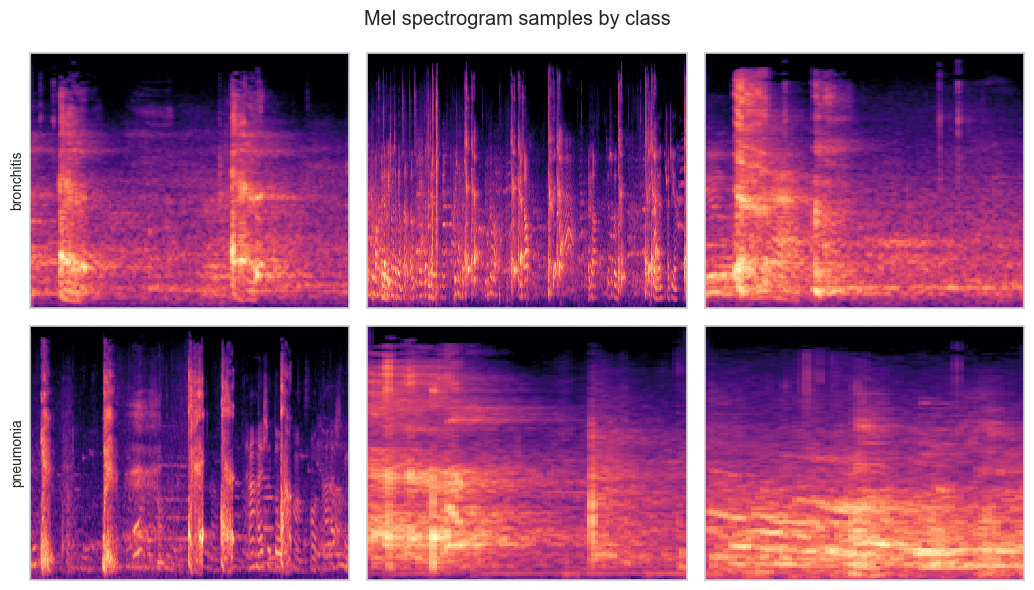

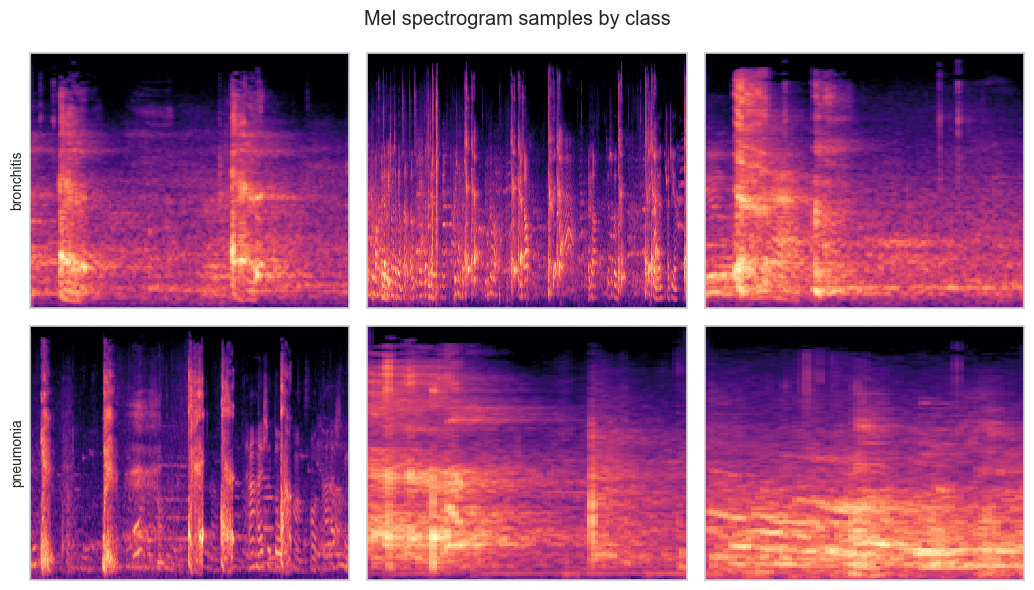

In [ ]:
fig = spectrogram_sample_grid(
    west_china_df, filepath_col="filepath", label_col="label", n_per_class=3
)
fig.savefig(ARTIFACTS_DIR / "west_china_spectrogram_grid.png", dpi=150)
fig

## 4. Cross-dataset checks

Once each dataset is profiled individually, this section looks at whether
and how they can be combined for a single model.


### 4.1 Schema alignment matrix

In [ ]:
schema_alignment_matrix({
    "coughvid": coughvid_df,
    "tb_metadata": tb_metadata_df,
    "west_china": west_china_df,
})

,coughvid,tb_metadata,west_china,present_in_n_datasets
age,True,True,False,2
Abnormal_quadrants_number_denominator_4,False,True,False,1
Label,False,True,False,1
Cavities - Y/N; if Y number of lobes,False,True,False,1
Number_of_quadrants_with_consolidation,False,True,False,1
Permission_sound,False,True,False,1
Primary findings,False,True,False,1
Unnamed: 0,False,True,False,1
all_device_cough_count,False,True,False,1
audio_name,True,False,False,1


### 4.2 Label taxonomy reconciliation

Explicit, version-controlled mapping of each dataset's raw labels to a unified target space. **Fill this in deliberately, don't leave it implicit.**

In [48]:
label_map = label_taxonomy_reconciliation({
    "coughvid": {
        "healthy": "negative",
        "symptomatic": "positive_respiratory",
        "COVID-19": "positive_respiratory",
    },
    "tb_screen": {
        "NTB": "negative",
        "TB": "positive_respiratory",
    },
    "west_china": {
        "bronchitis": "positive_respiratory",
        "pneumonia": "positive_respiratory",
    },
})
label_map

,dataset,raw_label,unified_label
0,coughvid,healthy,negative
1,coughvid,symptomatic,positive_respiratory
2,coughvid,COVID-19,positive_respiratory
3,tb_screen,NTB,negative
4,tb_screen,TB,positive_respiratory
5,west_china,bronchitis,positive_respiratory
6,west_china,pneumonia,positive_respiratory
